## Homework 2 Spring 2026
- Wed Jan 21 and Friday Jan 23, we covered Sec 3.1 - Simple linear Regression
  - 3.7.8 (a)(i,ii,iii, modified iv below) and (b)
    - *Modified version of a.iv:* 
      - What are the predicted values for the inputs? 
      - Compute the RSS and MSE using these predicted values.  
  - 3.7.13 
    - Warning for part (b), `np.random.normal` takes standard deviation as input for `scale`, not variance.
  - A note on code. The book's use of the `statsmodels` package is slightly different from the examples provided in the Jupyter notebooks in class. In particular, in the book's lab examples and in the homework statement they implicitly use

    ```python
    import statsmodels.api as sm
    ```

    while we use

    ```python
    import statsmodels.formula.api as smf
    ```

    This results in slight differences in code, in particular whether the function call you use is `OLS` or `ols`. You may use whichever works for you, the answers should be the same.

- Mon Jan 26, we cover Sec 3.2 - Multiple Linear Regression
  - 3.7.1
  - (*Modified version of 3.7.9*): Using the `Auto` data set, we will predict $Y = \texttt{mpg}$ using all other variables except name and origin. 
    - Generate the correlation matrix between all variables. Are there any pairs that are particularly highly correlated?
    - Using `statsmodel`, create a linear model predicting `mpg` from all other variables except `name` and `origin`.
    - Is there a relationship between the predictors and the response? Justify your answer.
    - Which predictors appear to have a statistically significant relationship to the response?
    - What does the coefficient for the year variable suggest?



### Grading distribution 

You should be able to break down the innards however you want. 

- 3.7.8 - 21 points 
- 3.7.13 - 38 points 
- 3.7.1 - 6 points
- 3.7.9ish - 11 points

In [35]:
# As always, we start with our favorite standard imports. 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
%matplotlib inline

import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression

&#9989; **<font color=red>Q 3.7.8 (21 points):</font>** This question involves the use of simple linear regression on the `Auto` data set.


In [36]:
# Load data 
# First, we're going to do all the data loading and cleanup we figured out last time.
url = "https://msu-cmse-courses.github.io/CMSE381-S26/_downloads/d75c3811a83a66f8c261e5b599ef9e44/Auto.csv"
auto = pd.read_csv(url)
auto = auto.replace('?', np.nan)
auto = auto.dropna()
auto.horsepower = auto.horsepower.astype('int')
auto.shape

(392, 9)

&#9989; **<font color=red>Q 3.7.8 (a) (5 points):</font>**

- (a) Use the sm.OLS() function to perform a simple linear regression with mpg as the response and horsepower as the predictor. Use the summarize() function to print the results. 


In [37]:
###YOUR sm.OLS() CODE HERE###

y = auto['mpg']
X = auto['horsepower']
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.606
Model:                            OLS   Adj. R-squared:                  0.605
Method:                 Least Squares   F-statistic:                     599.7
Date:                Thu, 05 Feb 2026   Prob (F-statistic):           7.03e-81
Time:                        23:05:56   Log-Likelihood:                -1178.7
No. Observations:                 392   AIC:                             2361.
Df Residuals:                     390   BIC:                             2369.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         39.9359      0.717     55.660      0.0

&#9989; **<font color=red>Q 3.7.8 (a)(i,ii,iii) (6 points):</font>**
Comment on the **(a)** output. For example:

    - i. Is there a relationship between the predictor and the response?
    - ii. How strong is the relationship between the predictor and the response?
    - iii. Is the relationship between the predictor and the response positive or negative?


*YOUR ANSWER TO (i),(ii), and (iii)*

- (i) There is a relationship between horsepower and mpg. Looking at the p - value for horsepower, the value is 0.000 which is lower than 0.05 so there is a significant relationship between the two

- (ii) The $R^2$ value = 0.606, means that about 60.6% of the variability in mpg can be explained by horsepower, which is moderately strong, and not the best.

- (iii) The relationship between the predictor and response is negative, looking at the coefficient for horsepower, which is -0.1578. So as horsepower increases, the mpg decreases.

&#9989; **<font color=red>Q 3.7.8 (a) (7 points):</font>**(modified iv below)
- What are the predicted values for the inputs? 
- Compute the RSS and MSE using these predicted values. 


In [39]:
###YOUR CODE OR ANSWER HERE###

y_pred = model.predict(X)
print(y_pred.head())

residuals = y - y_pred
RSS = np.sum(residuals**2)
print(f"RSS = {RSS}")

n = X.shape[0]
p = X.shape[1]
MSE = RSS / n
print(f"MSE = {MSE}")

# Based on the equation mpg = 39.9359 - 0.1578 * horsepower, the first car has a predicted mpg of 19.42, the second has 13.89, and so on.
# There are cars that have the same mpg, for example index 2 and 3, so that means that those cars have the same horsepower.

# The residual sum of squares is about 9385.92. This measures the total squared error between the observed mpg and the predicted mpg.

# The mean squared error is about 23.94. The mean squared error (MSE) is the average squared prediction error across all observations.

0    19.416046
1    13.891480
2    16.259151
3    16.259151
4    17.837598
dtype: float64
RSS = 9385.915871932419
MSE = 23.943662938603108


&#9989; **<font color=red>Q 3.7.8 (b) (3points):** 
- (b) Plot the response and the predictor in a new set of axes ax. Use the ax.axline() method or the abline() function defined in the lab to display the least squares regression line.


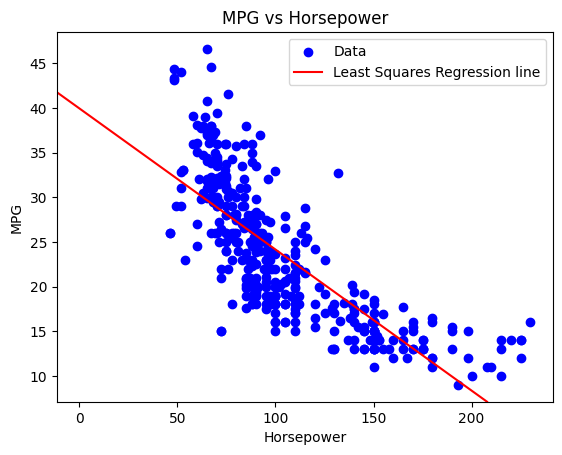

In [40]:
###YOUR CODE HERE####

fig, ax = plt.subplots()
ax.scatter(auto['horsepower'], auto['mpg'], color='blue', label='Data')
intercept = model.params['const']
slope = model.params['horsepower']
ax.axline((0, intercept), slope=slope, color='red', label='Least Squares Regression line')
ax.set_xlabel('Horsepower')
ax.set_ylabel('MPG')
ax.set_title('MPG vs Horsepower')
ax.legend()
plt.show()

#### &#9989;&nbsp; **Question 3.7.8 Documenting Your Solution Pathway (3 points)**

**Answer the following questions in detail:**
1. Indicate which portions of Question 3.7.8 you answered with prior knowledge, and also indicate which portions of Question 3.7.8 you answered with the help of outside sources (e.g. generative AI, past assignments, Stack Overflow, Google, etc.) to help you? (1 point)
2. **For the parts were you DID use external resources**, document what sources you used and how they informed your approach.  If you used generative AI, be sure to include the most important *prompts and outputs*. **For the parts where you DID NOT use external resources**, what prior knowledge did you recall to solve the problem? (2 points)

###YOUR ANSWER HERE (You can use markdown)###

1. I answered parts of Question 3.7.8 using a combination of prior knowledge and external resources. Prior knowledge was used for interpreting the OLS regression output, where CMSE 201 and 202 had a ton of assingments dealing with the same content. Also with understanding the meaning of predicted values, RSS, and MSE. Computing residuals, RSS, and MSE was done by using NumPy. Interpreting the regression coefficients and writing conclusions accomplished by using experience from previous CMSE classes. External resources were used for writing the Matplotlib plotting code, specifically how to correctly use ax.axline() to draw the least-squares regression line from the fitted statsmodels model.

2. ChatGPT (OpenAI) was used to help generate the plotting code for part (b), including creating a new set of axes using plt.subplots(). ChatGPT provided a working example showing how to extract the intercept and slope from model.params and correctly pass them to ax.axline(). I adapted that code to my dataset and model. Output: ax.axline((0, intercept), slope=slope, color='red', linewidth=2, label='Least Squares Regression line')

&#9989; **<font color=red> 3.7.13 (a) (2 points):**

In this exercise you will create some simulated data and will fit simple linear regression models to it. Make sure to use the default random number generator with seed set to 1 prior to starting part (a) to ensure consistent results.


- (a) Using the normal() method of your random number generator, create a vector, x, containing 100 observations drawn from a $N(0, 1)$ distribution. This represents a feature, $X$.


In [60]:
###YOUR CODE HERE####

np.random.seed(1)
x = np.random.normal(loc=0, scale=1, size=100)
x[:5]

array([ 1.62434536, -0.61175641, -0.52817175, -1.07296862,  0.86540763])

&#9989; **<font color=red> 3.7.13 (b) (2 points):**
Using the normal() method, create a vector, eps, containing 100 observations drawn from a N(0, 0.25) distribution—a normal distribution with mean zero and variance 0.25.


In [61]:
####YOUR CODE HERE####

eps = np.random.normal(loc=0, scale=0.5, size=100)
eps[:5]

array([-0.22356428,  0.61225385,  0.20174582,  0.29678926, -0.54745592])


&#9989; **<font color=red> 3.7.13 (c) (3points):** Using x and eps, generate a vector y according to the model

$$
Y = −1 + 0.5X + \varepsilon .
$$


What is the length of the vector $y$? What are the values of $\beta_0$  and $\beta_1$ in this linear model?


In [62]:
###YOUR CODE HERE###

y = -1 + 0.5 * x + eps
len(y)

# Length of vector $y = 100$. Values of beta_0 = -1 and beta_1 = 0.5

100

&#9989; **<font color=red> 3.7.13 (d) (2 points):** Create a scatterplot displaying the relationship between x and y. Comment on what you observe.


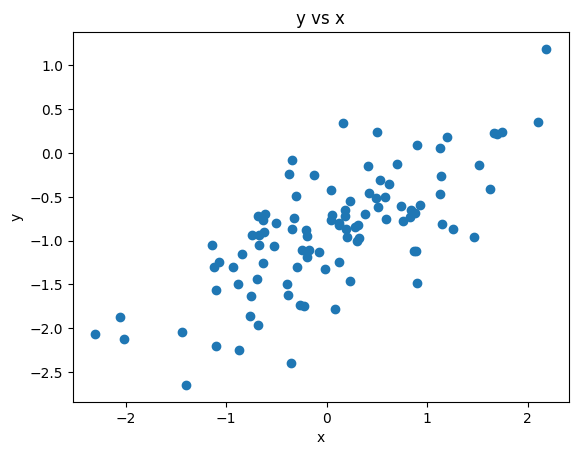

In [63]:
####YOUR CODE HERE###

plt.figure()
plt.scatter(x, y)
plt.xlabel("x")
plt.ylabel("y")
plt.title("y vs x")
plt.show()

# The scatter-plot shows a clear positive linear relationship between x and y. As x increases, y tends to increase as well.

&#9989; **<font color=red> 3.7.13 (e) (4 points):** Fit a least squares linear model to predict $y$ using $x$. Comment on the model obtained. How do $\hat\beta_0$ and $\hat\beta_1$ compare to $\beta_0$ and $\beta_1$?


In [64]:
####YOUR CODE HERE####

X = sm.add_constant(x)
model = sm.OLS(y, X).fit()
beta_0_hat, beta_1_hat = model.params

print(f"Estimated Intercept: {beta_0_hat:.4f}")
print(f"Estimated Slope: {beta_1_hat:.4f}")
print(f"\nTrue Intercept: -1")
print(f"True Slope: 0.5")

# The estimated coefficients beta_0_hat, -0.9265, and beta_1_hat, 0.5477, are very close to the true coefficients -1 and .5, respectively.
# The difference is because of random error added to the data.

Estimated Intercept: -0.9265
Estimated Slope: 0.5477

True Intercept: -1
True Slope: 0.5


&#9989; **<font color=red> 3.7.13 (f) (5 points):**
Display the least squares line on the scatterplot obtained in (d). Draw the population regression line on the plot, in a different color. Use the legend() method of the axes to create an appropriate legend.


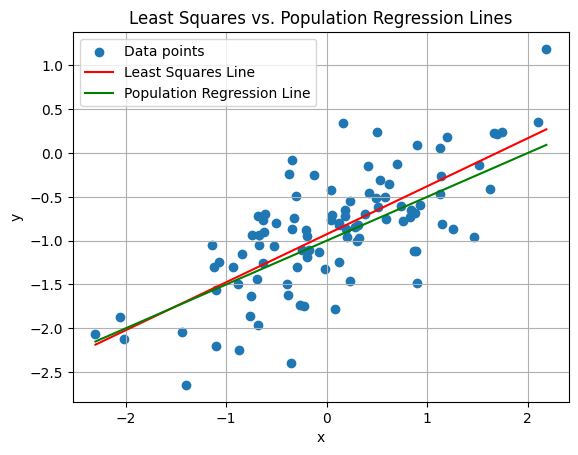

In [65]:
###YOUR CODE HERE###

x_plot = np.linspace(min(x), max(x), 100)
y_least_squares = beta_0_hat + beta_1_hat * x_plot
y_population = -1 + 0.5 * x_plot

plt.figure()
plt.scatter(x, y, label='Data points')
plt.plot(x_plot, y_least_squares, 'r-', label='Least Squares Line')
plt.plot(x_plot, y_population, 'g-', label='Population Regression Line')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Least Squares vs. Population Regression Lines')
plt.legend()
plt.grid(True)
plt.show()

&#9989; **<font color=red> 3.7.13 (g) (5 points):** Now fit a polynomial regression model that predicts y using x and $x^2$ . Is there evidence that the quadratic term improves the model fit? Explain your answer.



In [66]:
###YOUR CODE AND ANSWER HERE###

X_quad = sm.add_constant(np.column_stack([x, x**2]))
model_quad = sm.OLS(y, X_quad).fit()
print(model_quad.summary())

# The p-value for the quadratic term, p = 0.856, is very large, meaning it is not statistically significant.
# The coefficient for x^2 is 0.0077, which is very close to zero. This means the quadratic term has a very small effect, almost none, on the prediction.

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.522
Model:                            OLS   Adj. R-squared:                  0.512
Method:                 Least Squares   F-statistic:                     52.96
Date:                Thu, 05 Feb 2026   Prob (F-statistic):           2.83e-16
Time:                        23:09:48   Log-Likelihood:                -65.107
No. Observations:                 100   AIC:                             136.2
Df Residuals:                      97   BIC:                             144.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.9325      0.058    -16.158      0.0

&#9989; **<font color=red> 3.7.13 (h) (4 points):** Repeat (a)–(f) after modifying the data generation process in such a way that there is less noise in the data. The model (3.39) (Equation in 3.7.13 (c)) should remain the same. You can do this by decreasing the variance of the normal distribution used to generate the error term $\varepsilon$ in (b). Describe your results.


Estimated Intercept: -0.985299
Estimated Slope: 0.509543
True Intercept: -1
True Slope: 0.5


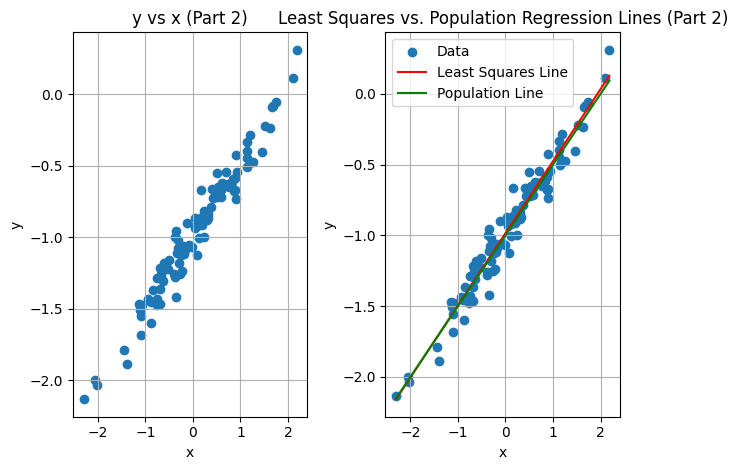

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.959
Model:                            OLS   Adj. R-squared:                  0.959
Method:                 Least Squares   F-statistic:                     2314.
Date:                Thu, 05 Feb 2026   Prob (F-statistic):           5.58e-70
Time:                        23:08:28   Log-Likelihood:                 95.820
No. Observations:                 100   AIC:                            -187.6
Df Residuals:                      98   BIC:                            -182.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.9853      0.009   -104.844      0.0

In [52]:
###YOUR CODE AND ANSWER HERE###

np.random.seed(1)
x = np.random.normal(0, 1, 100)
eps = np.random.normal(0, 0.1, 100)

y = -1 + 0.5 * x + eps

plt.figure()

plt.subplot(1, 2, 1)
plt.scatter(x, y)
plt.xlabel('x')
plt.ylabel('y')
plt.title('y vs x (Part 2)')
plt.grid(True)

coefficients = np.polyfit(x, y, 1)
beta_0_hat, beta_1_hat = coefficients[1], coefficients[0]

print(f"Estimated Intercept: {beta_0_hat:.6f}")
print(f"Estimated Slope: {beta_1_hat:.6f}")
print(f"True Intercept: -1")
print(f"True Slope: 0.5")

plt.subplot(1, 2, 2)
x_plot = np.linspace(min(x), max(x), 100)
y_least_squares = beta_0_hat + beta_1_hat * x_plot
y_population = -1 + 0.5 * x_plot

plt.scatter(x, y, label='Data')
plt.plot(x_plot, y_least_squares, 'r-', label='Least Squares Line')
plt.plot(x_plot, y_population, 'g-', label='Population Line')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Least Squares vs. Population Regression Lines (Part 2)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

X_linear = sm.add_constant(x)
model_linear = sm.OLS(y, X_linear).fit()
print(model_linear.summary())

# Plot: The low noise with ${\sigma} = 0.1$ scatter-plot shows points tightly clustered around a straight line compared to the first regression scatter-plot
# where there were a ton of varying points. The least squares line and population line are almost indistinguishable, and fit together very well.
# There is very little vertical spread in the data points. The estimated intercept and slope was also more accurate to the -1 intercept and 0.5 slope.

# OLS Regression Results: Looking at the $R^2$ values, the low noise rose to 0.959, compared to the first regression equation.
# This means 95.9% of the variance in y is explained by x, which is a massive improvement from 52.2% with the first regression model.
# Both p - values for the coefficient for constant and $x^1$ are 0 which perfect. This is a much better model compared to the original.

&#9989; **<font color=red> 3.7.13 (i) (4 points):** Repeat (a)–(f) after modifying the data generation process in such a way that there is more noise in the data. The model (3.39) should remain the same. You can do this by increasing the variance of the normal distribution used to generate the error term " in (b). Describe your results.


Estimated Intercept: -0.852986
Estimated Slope: 0.595427
True Intercept: -1
True Slope: 0.5


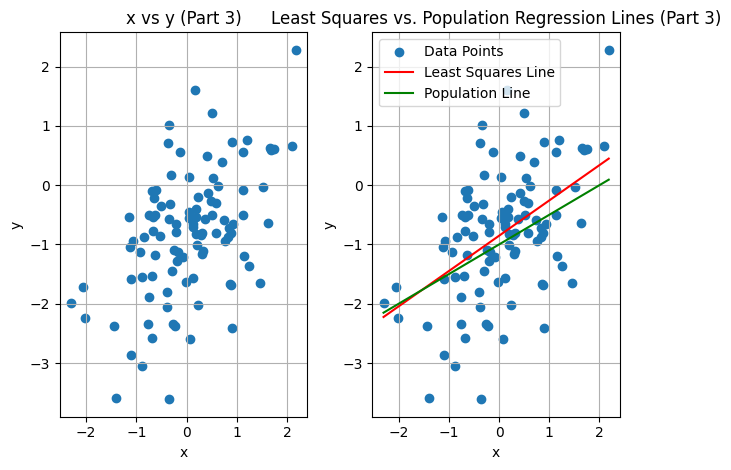

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.244
Model:                            OLS   Adj. R-squared:                  0.236
Method:                 Least Squares   F-statistic:                     31.60
Date:                Thu, 05 Feb 2026   Prob (F-statistic):           1.79e-07
Time:                        23:08:34   Log-Likelihood:                -134.44
No. Observations:                 100   AIC:                             272.9
Df Residuals:                      98   BIC:                             278.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.8530      0.094     -9.076      0.0

In [53]:
###YOUR CODE AND ANSWER HERE###

np.random.seed(1)
x = np.random.normal(0, 1, 100)
eps = np.random.normal(0, 1.0, 100)

y = -1 + 0.5 * x + eps

plt.figure()

plt.subplot(1, 2, 1)
plt.scatter(x, y)
plt.xlabel('x')
plt.ylabel('y')
plt.title('x vs y (Part 3)')
plt.grid(True)

coefficients = np.polyfit(x, y, 1)
beta_0_hat, beta_1_hat = coefficients[1], coefficients[0]

print(f"Estimated Intercept: {beta_0_hat:.6f}")
print(f"Estimated Slope: {beta_1_hat:.6f}")
print(f"True Intercept: -1")
print(f"True Slope: 0.5")

plt.subplot(1, 2, 2)
x_plot = np.linspace(min(x), max(x), 100)
y_least_squares = beta_0_hat + beta_1_hat * x_plot
y_population = -1 + 0.5 * x_plot

plt.scatter(x, y, label='Data Points')
plt.plot(x_plot, y_least_squares, 'r-', label='Least Squares Line')
plt.plot(x_plot, y_population, 'g-', label='Population Line')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Least Squares vs. Population Regression Lines (Part 3)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

X_linear = sm.add_constant(x)
model_linear = sm.OLS(y, X_linear).fit()
print(model_linear.summary())

# Plot: The high noise scatter-plot with ${\sigma} = 1.0$ shows points much more widely scattered around a straight line compared to both
# the original and low noise scatter-plots. The data points have vertical spread, making the linear pattern harder to look at visually.
# The least squares line and population line show divergence, less certain about the true relationship because of the increased noise.
# The estimated intercept was -0.852986, which was off by around 0.15. This deviation is much larger than in the low noise,
# which had a difference of around 0.02. The estimated slope was 0.595427, difference of 0.09.
# This is higher than the difference for low noise, which was 0.009.

# OLS Regression Results: Looking at the $R^2$ values, the high noise decreased to 0.244, compared to the original and low noise regression.
# This means only 24.4% of the variance in y is explained by x, which is a massive decline from 52.2% with the first regression model and 95.9% with the low noise.
# Both p - values for the coefficient for constant and $x^1$ are 0 which perfect. This model is worse than the original and low noise.

&#9989; **<font color=red> 3.7.13 (j) (2 points):** 1)What are the confidence intervals for $\beta_0$ and $\beta_1$ based on the original data set.

In [54]:
###YOUR CODE AND ANSWER HERE###

np.random.seed(1)
x = np.random.normal(0, 1, 100)
eps = np.random.normal(0, 0.5, 100)
y = -1 + 0.5 * x + eps

X = sm.add_constant(x)
model = sm.OLS(y, X).fit()

conf_int = model.conf_int()
print("95% Confidence Intervals Original Data:")
print(f"Intercept: [{conf_int[0, 0]:.4f}, {conf_int[0, 1]:.4f}]")
print(f"Slope: [{conf_int[1, 0]:.4f}, {conf_int[1, 1]:.4f}]")

# 95% Confidence Intervals Original Data: Intercept: [-1.0197, -0.8332]. Slope: [0.4426, 0.6528]

95% Confidence Intervals Original Data:
Intercept: [-1.0197, -0.8332]
Slope: [0.4426, 0.6528]


&#9989; **<font color=red> 3.7.13 (j) (2points):** 2)What are the confidence intervals for $\beta_0$ and $\beta_1$ based on the noisier data set.

In [55]:
###YOUR CODE AND ANSWER HERE###

np.random.seed(1)
x = np.random.normal(0, 1, 100)
eps = np.random.normal(0, 1.0, 100)
y = -1 + 0.5 * x + eps

X = sm.add_constant(x)
model = sm.OLS(y, X).fit()

conf_int = model.conf_int()
print("95% Confidence Intervals More Noisy Data:")
print(f"Intercept: [{conf_int[0, 0]:.4f}, {conf_int[0, 1]:.4f}]")
print(f"Slope: [{conf_int[1, 0]:.4f}, {conf_int[1, 1]:.4f}]")

# 95% Confidence Intervals More Noisy Data: Intercept: [-1.0395, -0.6665]. Slope: [0.3852, 0.8056]

95% Confidence Intervals More Noisy Data:
Intercept: [-1.0395, -0.6665]
Slope: [0.3852, 0.8056]


&#9989; **<font color=red> 3.7.13 (j) (2points):** 3)What are the confidence intervals for $\beta_0$ and $\beta_1$ based on the less noisy data set? Comment on your results.

In [56]:
###YOUR CODE AND ANSWER HERE###

np.random.seed(1)
x = np.random.normal(0, 1, 100)
eps = np.random.normal(0, 0.1, 100)
y = -1 + 0.5 * x + eps

X = sm.add_constant(x)
model = sm.OLS(y, X).fit()

conf_int = model.conf_int()
print("95% Confidence Intervals Less Noisy Data")
print(f"Intercept: [{conf_int[0, 0]:.4f}, {conf_int[0, 1]:.4f}]")
print(f"Slope: [{conf_int[1, 0]:.4f}, {conf_int[1, 1]:.4f}]")

# Comment: The width for the intercept is about 0.0373. The width for the slope is about 0.0412. Low noise is optimal for estimating data.

95% Confidence Intervals Less Noisy Data
Intercept: [-1.0039, -0.9666]
Slope: [0.4885, 0.5306]


&#9989; **<font color=red> 3.7.13 (j) (1 point):** 4)Please comment on your above three different confidence interval results.

###YOUR ANSWER HERE###

The confidence intervals show a very clear pattern of decreasing precision with increasing noise. Less noisy data $({\sigma} = 0.1)$: Very narrow intervals, with widths 0.037 and 0.042. Original data $({\sigma} = 0.5)$: Moderate intervals with widths 0.187 and 0.210. More noisy data $({\sigma} = 1.0)$: Very wide intervals with widths 0.373 and 0.420. With low noise, you can pinpoint the parameters within a narrow range. With high noise, the possible parameter values has a much wider range. Low noise gives precise estimates even with smaller sample sizes. High noise requires larger sizes to get the similar precision.

&#9989; **<font color=red> 3.7.1 (6 points):**

Describe the null hypotheses to which the p-values given in Table 3.4 correspond. Explain what conclusions you can draw based on these p-values. Your explanation should be phrased in terms of `sales`, `TV`, `radio`, and `newspaper`, rather than in terms of the coefficients of the linear model.

![](../../Lectures/Figures/Table3-4.png)

###YOUR ANSWER HERE###

#### Null Hypothesis:

For TV advertising: There is no relationship between TV advertising budget and sales, controlling for radio and newspaper advertising. Changes in TV advertising budget have no effect on sales when radio and newspaper budgets are held constant.

For radio advertising: There is no relationship between radio advertising budget and sales, controlling for TV and newspaper advertising. Changes in radio advertising budget have no effect on sales when TV and newspaper budgets are held constant.

For newspaper advertising: There is no relationship between newspaper advertising budget and sales, controlling for TV and radio advertising. Changes in newspaper advertising budget have no effect on sales when TV and radio budgets are held constant.

#### Conclusions Based on p-values:

TV advertising (p < 0.0001): Conclusion: Reject the null hypothesis. There is strong statistical evidence that TV advertising budget is related to sales, even after accounting for radio and newspaper advertising. Higher TV advertising budgets are associated with higher sales.

Radio advertising (p < 0.0001): Conclusion: Reject the null hypothesis. There is strong statistical evidence that radio advertising budget is related to sales, even after accounting for TV and newspaper advertising. Higher radio advertising budgets are associated with higher sales.

Newspaper advertising (p = 0.8599): Conclusion: Fail to reject the null hypothesis. There is no statistical evidence that newspaper advertising budget is related to sales when controlling for TV and radio advertising. Newspaper advertising spending appears to have no significant effect on sales in this model.

#### &#9989;&nbsp; **Question 3.7.1 Documenting Your Solution Pathway (3 points)**

**Answer the following questions in detail:**
1. Indicate which portions of question 3.7.1 you answered with prior knowledge, and also indicate which portions of question 3.7.1 you answered with the help of outside sources (e.g. generative AI, past assignments, Stack Overflow, Google, etc.) to help you? (1 point)
2. **For the parts were you DID use external resources**, document what sources you used and how they informed your approach.  If you used generative AI, be sure to include the most important *prompts and outputs*. **For the parts where you DID NOT use external resources**, what prior knowledge did you recall to solve the problem? (2 points)

YOUR ANSWER HERE (You can use markdown)

1. Prior Knowledge: Parts (a), (b), (c): Generating random normal variables and creating y from the linear model. Part (d): Creating scatterplots with matplotlib. Part (e): Basic linear regression fitting using np.polyfit(). Part (f): Plotting regression lines and adding legends, also understanding the statistical concepts: confidence intervals, $R^2$, p-values, noise effects. External Resources Used: Part (g): Quadratic model implementation and interpretation. Parts (h) and (i): Systematic modification of noise levels and comparative analysis. Part (j): 95% confidence interval extraction and formatting.

2. Confidence Interval Extraction: The parts that I did know were methods applied were all covered in previous assignments and labs in CMSE 201 and CMSE 202. The ChatGPT showed me the exact syntax and this was important because I knew the concept but needed the precise Python implementation. Prompt: "switch this code to match the OLS summary" Output: Proper statsmodels implementation showing how to extract and format results: print(f"Intercept: [{conf_int[0, 0]:.4f}, {conf_int[0, 1]:.4f}]") print(f"Slope: [{conf_int[1, 0]:.4f}, {conf_int[1, 1]:.4f}]").

&#9989; **<font color=red> Modified version of 3.7.9 (11 points):**  Using the `Auto` data set, we will predict $Y = \texttt{mpg}$ using all other variables except name. 


In [57]:
# Load data 
# First, we're going to do all the data loading and cleanup we figured out last time.
url = "https://msu-cmse-courses.github.io/CMSE381-S26/_downloads/d75c3811a83a66f8c261e5b599ef9e44/Auto.csv"
auto = pd.read_csv(url)
auto = auto.replace('?', np.nan)
auto = auto.dropna()
auto.horsepower = auto.horsepower.astype('int')
auto.shape

(392, 9)

&#9989; **<font color=red> Modified version of 3.7.9 (i) (3 points):**  
    - Generate the correlation matrix between all variables. Are there any pairs that are particularly highly correlated?

In [58]:
####YOUR CODE HERE###

auto.corr(numeric_only=True)

# There are a few pairs that are highly correlated. mpg is strongly negatively correlated with
# weight, displacement, horsepower, and cylinders.
# Cylinders, displacement, horsepower, and weight are strongly positively correlated with each other.

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
mpg,1.000000,-0.777618,-0.805127,-0.778427,-0.832244,0.423329,0.580541,0.565209
cylinders,-0.777618,1.000000,0.950823,0.842983,0.897527,-0.504683,-0.345647,-0.568932
displacement,-0.805127,0.950823,1.000000,0.897257,0.932994,-0.543800,-0.369855,-0.614535
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361,-0.455171
weight,-0.832244,0.897527,0.932994,0.864538,1.000000,-0.416839,-0.309120,-0.585005
acceleration,0.423329,-0.504683,-0.543800,-0.689196,-0.416839,1.000000,0.290316,0.212746
year,0.580541,-0.345647,-0.369855,-0.416361,-0.309120,0.290316,1.000000,0.181528
origin,0.565209,-0.568932,-0.614535,-0.455171,-0.585005,0.212746,0.181528,1.000000


&#9989; **<font color=red> Modified version of 3.7.9 (ii) (2 points):** 
    - Using `statsmodel`, create a linear model predicting `mpg` from all other variables except `name`.
    

In [59]:
###YOUR CODE HERE##

Y = auto['mpg']
X = auto.drop(columns=['mpg', 'name'])
X = sm.add_constant(X)
model = sm.OLS(Y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     252.4
Date:                Thu, 05 Feb 2026   Prob (F-statistic):          2.04e-139
Time:                        23:09:04   Log-Likelihood:                -1023.5
No. Observations:                 392   AIC:                             2063.
Df Residuals:                     384   BIC:                             2095.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -17.2184      4.644     -3.707      0.000     -26.350      -8.087
cylinders       -0.4934      0.323     -1.526      0.128      -1.129       0.142
displacement     0.0199      0.008      2.647      0.008       0.005       0.035
horsepower      -0.0170      0.014     -1.230      0.220      -0.044       0.010
weight          -0.0065      0.001     -9.929      0.000      -0.008      -0.005
acceleration     0.0806      0.099      0.815      0.415      -0.114       0.275
year             0.7508      0.051     14.729      0.000       0.651       0.851
origin           1.4261      0.278      5.127      0.000       0.879       1.973
==============================================================================
Omnibus:                       31.906   Durbin-Watson:                   1.309
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               53.100
Skew:                           0.529   Prob(JB):                     2.95e-12
Kurtosis:                       4.460   Cond. No.                     8.59e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 8.59e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

&#9989; **<font color=red> Modified version of 3.7.9 (iii) (1 point):**  
- Is there a relationship between the predictors and the response? Justify your answer.
    

##YOUR ANSWER HERE###

Yes, there is a relationship between the predictors and mpg. The overall F-test, 252.4, is highly significant, showing that at least one predictor is related to mpg and the large R^2 value, 0.821, shows the predictors explain a very large portion of the variability in the response, 82.1%.

&#9989; **<font color=red> Modified version of 3.7.9 (iv) (1 point):**  
    - Which predictors appear to have a statistically significant relationship to the response?
    

###YOUR ANSWER HERE###

Statistically significant predictors are p - values that are less than 0.05. This includes displacement (p = 0.008), weight (p < 0.001), year (p < 0.001), and origin (p < 0.001). These predictors have a statistically significant relationship with mpg.

&#9989; **<font color=red> Modified version of 3.7.9 (iii) (1 point):**  
    - What does the coefficient for the year variable suggest?

###YOUR ANSWER HERE###

The coefficient for year is 0.7508, so each model year has an increase of about 0.75 miles per gallon in fuel efficiency. The positive coefficient for year means that newer cars usually have higher mpg. For each one-year increase in model year, the average mpg increases by about 0.75.

#### &#9989;&nbsp; **Question 3.7.9 Documenting Your Solution Pathway (3 points)**

**Answer the following questions in detail:**
1. Indicate which portions of Question 3.7.9 you answered with prior knowledge, and also indicate which portions of Question 3.7.9 you answered with the help of outside sources (e.g. generative AI, past assignments, Stack Overflow, Google, etc.) to help you? (1 point)
2. **For the parts were you DID use external resources**, document what sources you used and how they informed your approach.  If you used generative AI, be sure to include the most important *prompts and outputs*. **For the parts where you DID NOT use external resources**, what prior knowledge did you recall to solve the problem? (2 points)

YOUR ANSWER HERE

1. Most portions of Question 3.7.9 were completed using prior knowledge from other coursework, especially CMSE 201 and CMSE 202, where I learned how to compute and interpret correlation matrices, fit multiple linear regression models, and interpret regression output. Because of this background, no outside resources were required for the majority of the problem. Some small details about data analysis were helpful on Google, but the overall approach and interpretation came from older experience.

2. No external resources were used to solve the problem conceptually. The methods applied were all covered in previous assignments and labs in CMSE 201 and CMSE 202. Some things that I remembered were how to use .corr() to examine relationships between variables, how to build a linear regression model using statsmodels.OLS, how to interpret statistical significance using p-values, and how to interpret regression coefficients. I did have to search up in the very beginning coding auto.corr, because the data was not clean. A search on google told me to code it like auto.corr(numeric_only=True).